<h1>FFNN From Scratch</h1>
<h2>Weight Initializer Analysis</h2>

<h3>Configure Root</h3>

In [22]:
import sys
from pathlib import Path as path

root = path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))


<h3>Import Library</h3>

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from src.model.layers      import FFNN
from src.model.optimizer   import GradientDescent, AdaptiveMomentEstimation
from src.utils.data_loader import DataLoader
from src.utils.visualization import Visualizer


<h3>Importing Data</h3>

In [24]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val,   y_val   = loader.get_val()
X_test,  y_test  = loader.get_test()

X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val,   dtype=np.float64)
X_test  = np.asarray(X_test,  dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_val   = np.asarray(y_val,   dtype=np.float64)
y_test  = np.asarray(y_test,  dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim: {INPUT_DIM}')
print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')


[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

                          Head Dataset                           


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed



                      Datatypes Dataset===                       
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 9

None


                     Informasi Missing Data                      


...

np.int64(0)


                  Informasi Outlier (Metode IQR                  
cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers

                   Informasi Distribusi Target                   


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64

[DataLoader] Data di-split: 8000 Train, 2000 Test



               Informasi Outlier Setelah Clipping                
cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers
[DataLoader] Preprocessing selesai.
[DataLoader] X_train : (6400, 21) | y_train : (6400,)
[DataLoader] X_val   : (1600, 21)   | y_val   : (1600,)
Input dim: 21
Train: (6400, 21)
Val:   (1600, 21)
Test:  (2000, 21)


<h3>Initialize Model</h3>

In [25]:
HIDDEN_DIM        = [256, 128, 64]
EPOCHS            = 50
BATCH_SIZE        = 32
LR                = 1e-4
HIDDEN_ACTIVATION = 'relu'
OUTPUT_ACTIVATION = 'sigmoid'
LOSS_NAME         = 'bce'
SEED              = 42

ARCH = dict(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    seed              = SEED,
    init_method        = 'normal',
)

model_gd = FFNN(**ARCH)
model_adam = FFNN(**ARCH)

[FFNN] architecture initialized with: 21 -> 256 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: normal, seed=42
[FFNN] architecture initialized with: 21 -> 256 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: normal, seed=42


<h3>Train Models</h3>

In [26]:
# Setiap model mendapat optimizer-nya sendiri
optimizer_gd = GradientDescent(lr=LR)
optimizer_adam = AdaptiveMomentEstimation(lr=LR)
viz = Visualizer()

models = [
    ('Gradient Descent', model_gd, optimizer_gd),
    ('AdaptiveMomentEstimation', model_adam, optimizer_adam),
]

for name, model, optimizer in models:
    viz.print_section_term(f'Training {name}')
    for epoch in range(1, EPOCHS + 1):
        metrics = model.train_epoch(
            X_train, y_train,
            optimizer  = optimizer,
            batch_size = BATCH_SIZE,
            x_val      = X_val,
            y_val      = y_val,
        )
        print(f"Epoch {epoch:03d}/{EPOCHS} "
              f"Train loss: {metrics['train_loss']:.4f}, acc: {metrics['train_acc']:.4f} "
              f"Val loss: {metrics['val_loss']:.4f}, acc: {metrics['val_acc']:.4f}")



                    Training Gradient Descent                    
Epoch 001/50 Train loss: 0.7158, acc: 0.4067 Val loss: 0.7139, acc: 0.4050
Epoch 002/50 Train loss: 0.7123, acc: 0.4172 Val loss: 0.7103, acc: 0.4106
Epoch 003/50 Train loss: 0.7089, acc: 0.4281 Val loss: 0.7069, acc: 0.4219
Epoch 004/50 Train loss: 0.7058, acc: 0.4431 Val loss: 0.7038, acc: 0.4331
Epoch 005/50 Train loss: 0.7028, acc: 0.4575 Val loss: 0.7007, acc: 0.4475
Epoch 006/50 Train loss: 0.6999, acc: 0.4709 Val loss: 0.6979, acc: 0.4706
Epoch 007/50 Train loss: 0.6972, acc: 0.4895 Val loss: 0.6951, acc: 0.4988
Epoch 008/50 Train loss: 0.6947, acc: 0.5077 Val loss: 0.6925, acc: 0.5194
Epoch 009/50 Train loss: 0.6922, acc: 0.5206 Val loss: 0.6900, acc: 0.5375
Epoch 010/50 Train loss: 0.6899, acc: 0.5328 Val loss: 0.6877, acc: 0.5413
Epoch 011/50 Train loss: 0.6877, acc: 0.5484 Val loss: 0.6854, acc: 0.5613
Epoch 012/50 Train loss: 0.6855, acc: 0.5586 Val loss: 0.6832, acc: 0.5737
Epoch 013/50 Train loss: 0.6835, 

<h3>Plot Visualization</h3>


                           Loss Curve                            
[Visualizer] saved in ../results/initializer_comparison_loss.png


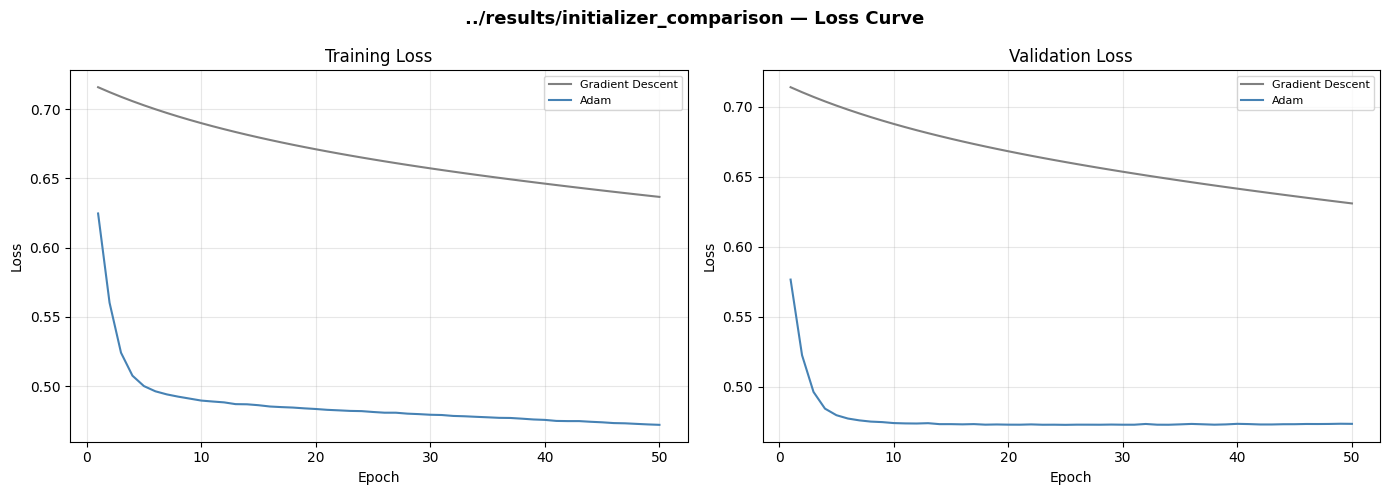


                       Weight Distribution                       
[Visualizer] saved in ../results/initializer_comparison_weights.png


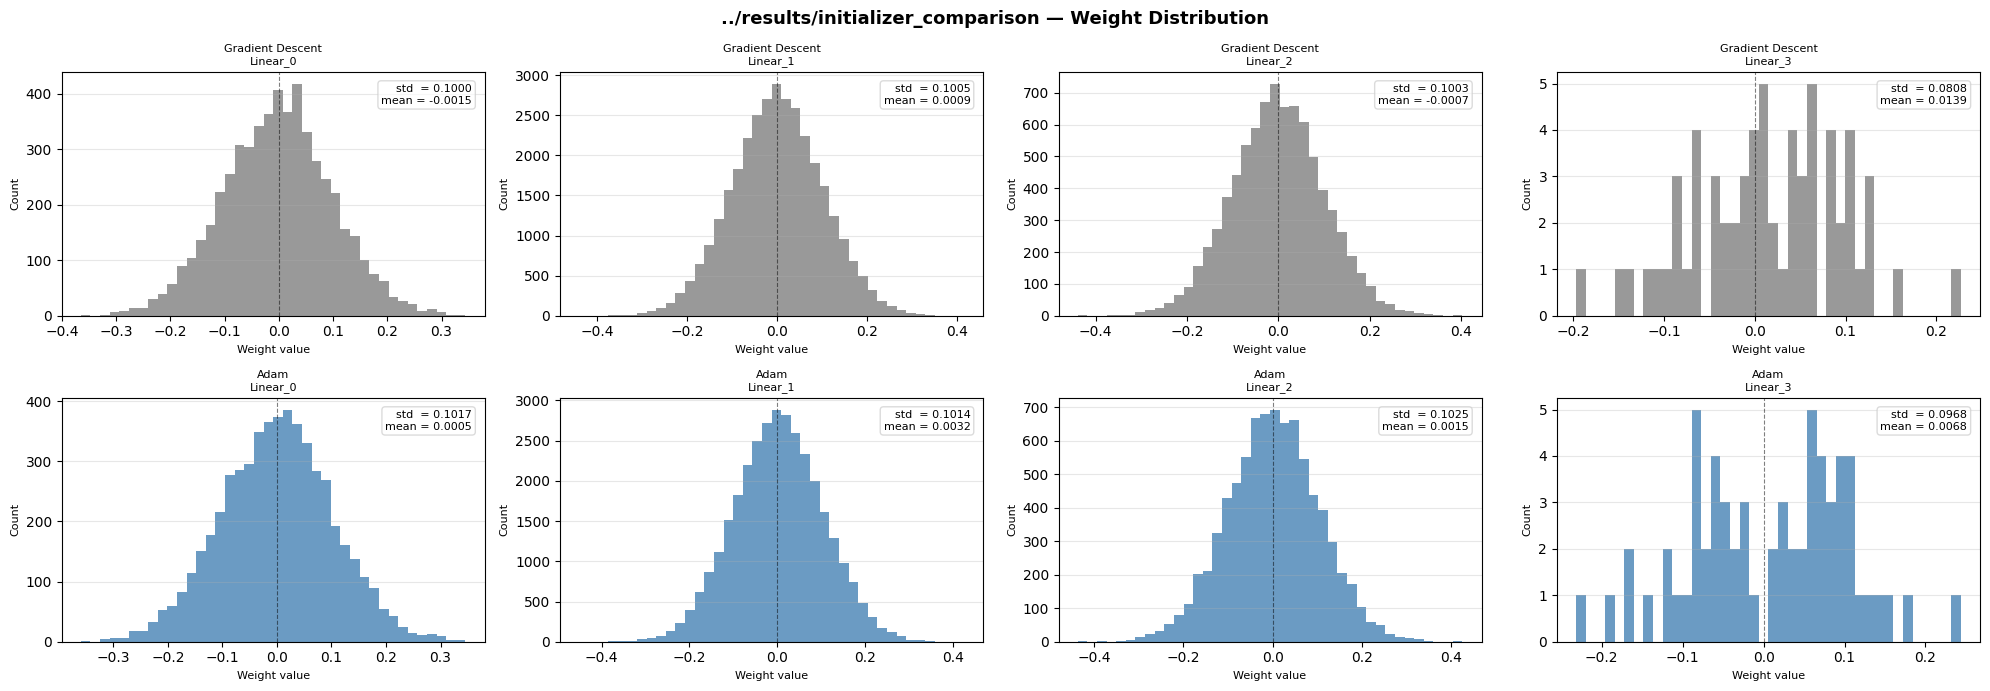


                      Gradient Distribution                      
[Visualizer] saved in ../results/initializer_comparison_grads.png


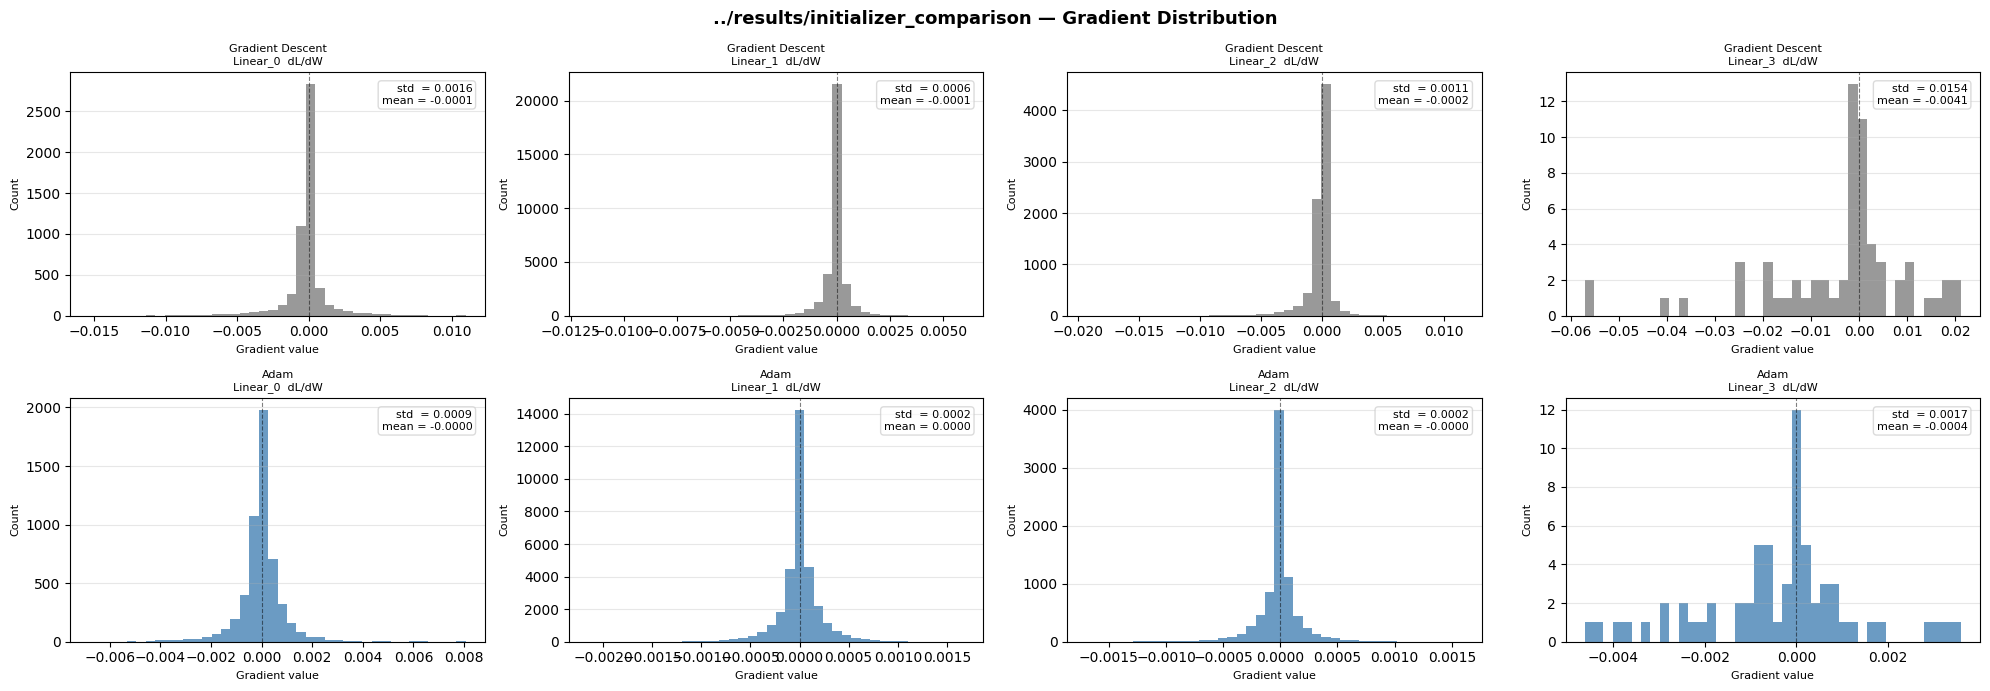


                       Final Test Accuracy                       
Initializer  | Accuracy
-------------------------
Gradient Descent |   0.6415
Adam         |   0.7455


In [27]:
results = {
    'Gradient Descent'    : {'history': model_gd.get_training_history(), 'model': model_gd, 'color': 'gray'},
    'Adam' : {'history': model_adam.get_training_history(), 'model': model_adam, 'color': 'steelblue'},
}

# # Normal (skala loss besar, ditampilkan terpisah)
# results_unstable = {k: results[k] for k in ['Normal', 'Zero']}

# #  Uniform, Xavier, He (skala loss normal ~0.5)
# results_stable = {k: results[k] for k in ['Zero', 'Uniform', 'Xavier', 'He', 'Normal']}

# viz.print_section_term('Loss Curve — Normal')
# viz.plot_comparison(
#     results=results_unstable,
#     mode='loss',
#     save_prefix='../results/initializer_unstable'
# )

# viz.print_section_term('Loss Curve — Zero, Uniform, Xavier, He')
# viz.plot_comparison(
#     results=results_stable,
#     mode='loss',
#     save_prefix='../results/initializer_stable'
# )

viz.print_section_term('Loss Curve')
viz.plot_comparison(
    results=results,
    mode='loss',
    save_prefix='../results/initializer_comparison'
)

viz.print_section_term('Weight Distribution')
viz.plot_comparison(
    results=results,
    mode='weights',
    save_prefix='../results/initializer_comparison'
)

viz.print_section_term('Gradient Distribution')
viz.plot_comparison(
    results=results,
    mode='grads',
    save_prefix='../results/initializer_comparison',
    x_ref=X_val,
    y_ref=y_val
)

viz.print_section_term('Final Test Accuracy')
print(f"{'Initializer':<12} | {'Accuracy':>8}")
print('-' * 25)
for name, r in results.items():
    y_pred = r['model'].predict(X_test)
    acc = float((y_pred == y_test).mean())
    print(f'{name:<12} | {acc:>8.4f}')


<h3>Save Models</h3>

In [28]:
os.makedirs('../output', exist_ok=True)

for name, r in results.items():
    fname = name.lower()
    r['model'].save(f'../output/{fname}_initializer')


[FFNN] Model tersimpan di '../output/gradient descent_initializer' 
[FFNN] Model tersimpan di '../output/adam_initializer' 
